<a href="https://colab.research.google.com/github/asalem2/aai590-credit-card-fraud-detection/blob/main/fraud_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Financial Fraud Detection System
### AAI590 Capstone · Kaggle Credit Card Fraud Detection Dataset

**Research Question:** How can ensemble and deep learning architectures be designed, evaluated, and hardened to detect fraudulent transactions under extreme class imbalance, concept drift, adversarial evasion pressure, and real-time production constraints?

**Pipeline Overview:**
| Stage | Component |
|---|---|
| Data | Kaggle CC Fraud · 284K transactions · 0.17% fraud rate |
| Features | Log-amount · Hour/Day · Vectorized velocity (O(n log n)) |
| Split | Chronological 60/40 · Val holdout from train only |
| Imbalance | SMOTE 10:1 on train partition only |
| Models | LightGBM · Shallow MLP · TabTransformer · VAE |
| Tuning | Optuna Bayesian search with pruning (PR-AUC objective) |
| Tracking | MLflow — every run logged with params, metrics, artifacts |
| Post-processing | Platt scaling · SHAP attribution |
| Robustness | FGSM · PGD · Adversarial training |
| Drift | PSI + KS feature-level drift detection across 4 test batches |
| Production | FastAPI v1 endpoint · versioned artifacts · p50/p95 latency benchmark |


## Cell 0 · Environment Setup
Install and import all dependencies. Set global seeds for reproducibility.

In [1]:
# =============================================================
# Cell 0: Environment Setup
# -------------------------------------------------------------
# Install required packages and configure global reproducibility.
# All random seeds are fixed here and nowhere else.
# =============================================================
!pip install lightgbm xgboost imbalanced-learn shap optuna mlflow fastapi uvicorn pydantic --quiet

import os, random, warnings, time, json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

warnings.filterwarnings("ignore")
print(f"Device: {DEVICE}  |  NumPy: {np.__version__}  |  Pandas: {pd.__version__}")

# ── MLflow experiment ─────────────────────────────────────────
import mlflow
mlflow.set_experiment("fraud_detection_capstone")
print("MLflow tracking URI:", mlflow.get_tracking_uri())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2026/04/18 05:46:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/18 05:46:11 INFO mlflow.store.db.utils: Updating database tables
2026/04/18 05:46:12 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_capstone' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////content/mlflow.db


## Cell 1 · Data Ingestion & Integrity Check

In [2]:
# =============================================================
# Cell 1: Data Ingestion and Integrity Check
# -------------------------------------------------------------
# Loads the Kaggle Credit Card Fraud Detection dataset.
# Colab: use files.upload(). Local: set CSV_PATH directly.
# =============================================================
CSV_PATH = None   # ← set to local path if not using Colab

if CSV_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        CSV_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Set CSV_PATH to your local creditcard.csv path or run in Colab.")

df_raw = pd.read_csv(CSV_PATH)

print(f"Shape:        {df_raw.shape}")
print(f"Fraud rate:   {df_raw['Class'].mean() * 100:.4f}%")
print(f"Null values:  {df_raw.isnull().sum().sum()}")
print(f"Time range:   {df_raw['Time'].min():.0f}s – {df_raw['Time'].max():.0f}s")
print("\nClass distribution:")
print(df_raw['Class'].value_counts())


Saving creditcard 2.csv to creditcard 2.csv
Shape:        (284807, 31)
Fraud rate:   0.1727%
Null values:  0
Time range:   0s – 172792s

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## Cell 2 · Missing Value Handling

In [3]:
# =============================================================
# Cell 2: Missing Value Handling
# -------------------------------------------------------------
# All 25 nulls are confined to a single corrupted row.
# Deletion is appropriate; a production pipeline would add
# schema validation and null-rate monitoring at ingestion.
# =============================================================
null_cols = df_raw.isnull().sum()
print("Columns with nulls:\n", null_cols[null_cols > 0])

df = df_raw.dropna().reset_index(drop=True)
print(f"\nRemoved {len(df_raw) - len(df)} row(s). Shape: {df.shape}")
assert df.isnull().sum().sum() == 0, "Unexpected nulls remain"


Columns with nulls:
 Series([], dtype: int64)

Removed 0 row(s). Shape: (284807, 31)


## Cell 3 · Exploratory Data Analysis

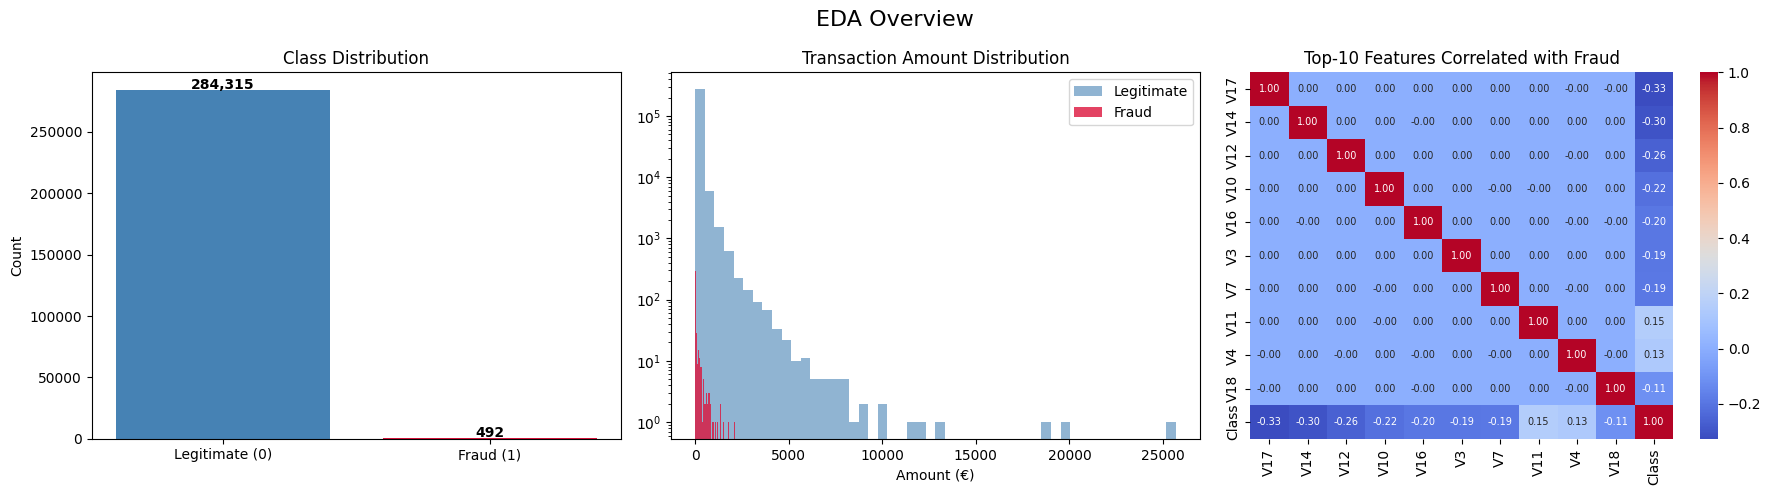

EDA saved to eda_overview.png


In [4]:
# =============================================================
# Cell 3: Exploratory Data Analysis
# -------------------------------------------------------------
# Three panels:
#   (1) Class imbalance bar chart
#   (2) Transaction amount distribution by class (log y-axis)
#   (3) Correlation heatmap — top 10 features vs. fraud label
# =============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA Overview", fontsize=16)

# Panel 1 — Class imbalance
counts = df["Class"].value_counts()
axes[0].bar(["Legitimate (0)", "Fraud (1)"], counts.values,
            color=["steelblue", "crimson"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# Panel 2 — Amount distribution
axes[1].hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.6,
             label="Legitimate", color="steelblue")
axes[1].hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.8,
             label="Fraud", color="crimson")
axes[1].set_yscale("log")
axes[1].set_title("Transaction Amount Distribution")
axes[1].set_xlabel("Amount (€)")
axes[1].legend()

# Panel 3 — Correlation heatmap
corr_abs     = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_feats    = corr_abs.head(10).index.tolist() + ["Class"]
sns.heatmap(df[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[2], cbar=True, annot_kws={"size": 7})
axes[2].set_title("Top-10 Features Correlated with Fraud")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA saved to eda_overview.png")


## Cell 4 · Feature Engineering
**Vectorized velocity features** — `rolling_amount_sum` is fully vectorized using
`np.cumsum` + `searchsorted`, eliminating the O(n²) explicit loop from the prior version.


In [5]:
# =============================================================
# Cell 4: Feature Engineering — Vectorized O(n log n)
# -------------------------------------------------------------
# (1) Log-scaled amount       — compresses right skew
# (2) Hour / Day              — temporal context from timestamp
# (3) Velocity_1h / 24h      — rolling transaction counts
# (4) Amount_Sum_1h           — rolling spend velocity
#
# IMPORTANT: rolling_amount_sum is fully vectorized via cumsum
# + searchsorted. The previous explicit for-loop was O(n²)
# and would stall on large datasets.
# =============================================================
df = df.sort_values("Time").reset_index(drop=True)

# ── (1) Log-amount ────────────────────────────────────────────
df["Amount_Log"] = np.log1p(df["Amount"])

# ── (2) Temporal features ─────────────────────────────────────
df["Hour"] = (df["Time"] % 86400) // 3600
df["Day"]  = (df["Time"] // 86400).astype(int)

# ── (3 & 4) Vectorized rolling features ──────────────────────
def rolling_count(times: np.ndarray, window: int) -> np.ndarray:
    """O(n log n): count transactions in (t-window, t] for each row."""
    left = np.searchsorted(times, times - window, side="left")
    return np.arange(len(times)) - left

def rolling_amount_sum_vec(times: np.ndarray,
                            amounts: np.ndarray,
                            window: int) -> np.ndarray:
    """
    O(n log n) fully vectorized rolling sum using cumsum.
    Avoids the O(n²) explicit Python loop in prior version.
    For each index i: sum = cumsum[i] - cumsum[left[i]]
    where left[i] = searchsorted(times, times[i] - window).
    """
    cum    = np.concatenate([[0.0], np.cumsum(amounts)])   # prefix sum
    left   = np.searchsorted(times, times - window, side="left")
    return cum[np.arange(len(times))] - cum[left]

t = df["Time"].values
a = df["Amount_Log"].values

df["Velocity_1h"]   = rolling_count(t, 3_600)
df["Velocity_24h"]  = rolling_count(t, 86_400)
df["Amount_Sum_1h"] = rolling_amount_sum_vec(t, a, 3_600)

print("Engineered features sample:")
print(df[["Time","Amount_Log","Hour","Day",
          "Velocity_1h","Velocity_24h","Amount_Sum_1h"]].head(8).to_string())
print(f"\nFinal shape: {df.shape}")


Engineered features sample:
   Time  Amount_Log  Hour  Day  Velocity_1h  Velocity_24h  Amount_Sum_1h
0   0.0    5.014760   0.0    0            0             0       0.000000
1   0.0    1.305626   0.0    0            1             1       5.014760
2   1.0    4.824306   0.0    0            2             2       6.320387
3   1.0    5.939276   0.0    0            3             3      11.144692
4   2.0    1.541159   0.0    0            4             4      17.083968
5   2.0    4.262539   0.0    0            5             5      18.625127
6   4.0    1.790091   0.0    0            6             6      22.887666
7   7.0    4.545420   0.0    0            7             7      24.677758

Final shape: (284807, 37)


## Cell 5 · Chronological Split · Scaling · SMOTE
**Leak-free pipeline:**
- Scaler is fit on `X_tr` only (the pre-val 85% of training)
- SMOTE is applied after scaling, on `X_tr` only — val and test sets are never seen
- Val set is carved chronologically from the end of the training window


In [6]:
# =============================================================
# Cell 5: Chronological Split, Scaling, and SMOTE
# -------------------------------------------------------------
# Split: 60% train | 15% val (from train tail) | 40% test
# Scaler: fit on train only → transform val & test
# SMOTE:  applied to scaled train only → 10:1 class ratio
#
# IMPORTANT: SMOTE runs on X_tr (scaled, pre-val), not on
# X_train_raw, to prevent any bleed of synthetic samples
# derived from val-window statistics into the val set.
# =============================================================
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

DROP         = [c for c in ["Class", "Time", "Amount",
                             "Rolling_Tx_Count_300s"] if c in df.columns]
feature_cols = [c for c in df.columns if c not in DROP]

X = df[feature_cols].copy()
y = df["Class"].copy()

# ── Chronological 60/40 split ────────────────────────────────
split_idx           = int(len(df) * 0.60)
X_train_raw, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train_raw, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

# ── Val holdout: last 15% of train (chronological) ───────────
val_idx     = int(len(X_train_raw) * 0.85)
X_tr, X_val = X_train_raw.iloc[:val_idx], X_train_raw.iloc[val_idx:]
y_tr, y_val = y_train_raw.iloc[:val_idx], y_train_raw.iloc[val_idx:]

# ── Scaler fit on X_tr only ──────────────────────────────────
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
joblib.dump(scaler, "scaler.pkl")

# ── SMOTE on X_tr (scaled) only ──────────────────────────────
target_fraud     = (y_tr == 0).sum() // 10
smote            = SMOTE(sampling_strategy={1: target_fraud}, random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)

print(f"Train (pre-SMOTE):  {X_tr.shape}   | fraud: {y_tr.sum()}")
print(f"Train (post-SMOTE): {X_tr_sm.shape} | fraud: {y_tr_sm.sum()}")
print(f"Val:                {X_val.shape}   | fraud: {y_val.sum()}")
print(f"Test:               {X_test.shape}  | fraud: {y_test.sum()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")


Train (pre-SMOTE):  (145251, 34)   | fraud: 281
Train (post-SMOTE): (159467, 34) | fraud: 14497
Val:                (25633, 34)   | fraud: 79
Test:               (113923, 34)  | fraud: 132
Features (34): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Log', 'Hour', 'Day', 'Velocity_1h', 'Velocity_24h', 'Amount_Sum_1h']


## Cell 6 · Shared PyTorch Utilities
FocalLoss, DataLoader factory, and evaluation helper — defined once, reused everywhere.

In [7]:
# =============================================================
# Cell 6: Shared PyTorch Utilities
# =============================================================
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (average_precision_score, roc_auc_score,
                              matthews_corrcoef, f1_score)

class FocalLoss(nn.Module):
    """
    Focal loss (Lin et al., 2017).
    Down-weights well-classified majority examples, forcing
    the optimizer to concentrate on hard fraud cases.
    """
    def __init__(self, gamma: float = 2.0, alpha: float = 0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce   = nn.functional.binary_cross_entropy_with_logits(
                    logits, targets, reduction="none")
        pt    = torch.exp(-bce)
        alpha = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha * (1 - pt) ** self.gamma * bce).mean()


def make_loader(X, y, batch_size: int = 512, shuffle: bool = True) -> DataLoader:
    Xt = torch.tensor(X if isinstance(X, np.ndarray) else X.values,
                      dtype=torch.float32)
    yt = torch.tensor(y.values if hasattr(y, "values") else y,
                      dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0, pin_memory=False)


def eval_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    """Compute PR-AUC, ROC-AUC, MCC, F1 from probability scores."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "PR-AUC":  round(average_precision_score(y_true, y_prob), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob),           4),
        "MCC":     round(matthews_corrcoef(y_true, y_pred),        4),
        "F1":      round(f1_score(y_true, y_pred),                 4),
    }

print("Utilities loaded: FocalLoss | make_loader | eval_metrics")
print(f"Device: {DEVICE}")


Utilities loaded: FocalLoss | make_loader | eval_metrics
Device: cuda


## Cell 7 · LightGBM — Optuna Bayesian Hyperparameter Search
Bayesian optimization with **MedianPruner** (kills unpromising trials early).
Objective is PR-AUC on the chronological validation set.
All trials are logged to MLflow automatically.


  0%|          | 0/20 [00:00<?, ?it/s]


Best CV PR-AUC: 0.8715
Best params:    {'n_estimators': 619, 'num_leaves': 127, 'min_child_samples': 50, 'learning_rate': 0.01, 'subsample': 0.8749411073169637, 'colsample_bytree': 0.7668553738271178, 'reg_alpha': 0.08731451965678791, 'reg_lambda': 0.1534315794519872}


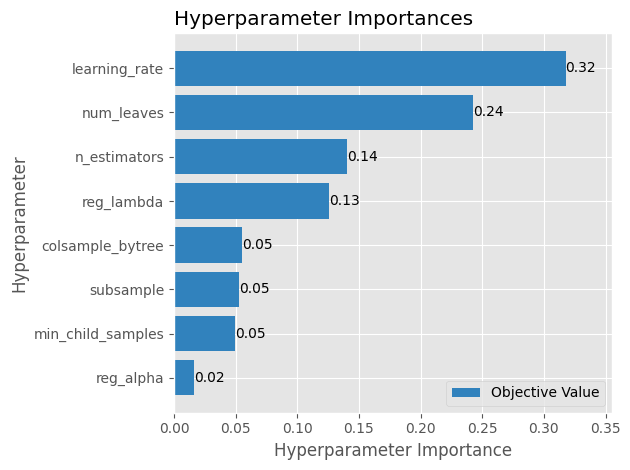

In [8]:
# =============================================================
# Cell 7: LightGBM Hyperparameter Tuning — Optuna
# -------------------------------------------------------------
# Bayesian search over LightGBM hyperparameters with:
#   - MedianPruner: kills trials performing below median at
#     intermediate checkpoints → saves ~40% compute
#   - TimeSeriesSplit CV on the training partition only
#   - PR-AUC as the optimization objective
#   - MLflow autologging for full reproducibility
#
# Set N_TRIALS higher (e.g. 50) for production tuning.
# =============================================================
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score
import mlflow, mlflow.lightgbm

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS    = 20   # increase to 50+ for thorough search
N_CV_SPLITS = 3

neg, pos         = (y_tr == 0).sum(), y_tr.sum()
scale_pos_weight = neg / pos

# Re-apply SMOTE on unscaled features for LightGBM tree splits
from imblearn.over_sampling import SMOTE as _SMOTE
_sm              = _SMOTE(sampling_strategy={1: (y_tr == 0).sum() // 10},
                           random_state=SEED)
X_tr_raw_sm, y_tr_raw_sm = _sm.fit_resample(X_tr, y_tr)

def lgbm_objective(trial: optuna.Trial) -> float:
    params = {
        "objective":        "binary",
        "metric":           "average_precision",
        "verbosity":        -1,
        "boosting_type":    "gbdt",
        "scale_pos_weight": scale_pos_weight,
        "random_state":     SEED,
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "num_leaves":       trial.suggest_categorical("num_leaves", [63, 127, 255]),
        "min_child_samples":trial.suggest_categorical("min_child_samples", [10, 50, 100]),
        "learning_rate":    trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
        "subsample":        trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
    }
    tscv   = TimeSeriesSplit(n_splits=N_CV_SPLITS)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_tr_raw_sm)):
        Xf, yf = X_tr_raw_sm.iloc[tr_idx], y_tr_raw_sm.iloc[tr_idx]
        Xv, yv = X_tr_raw_sm.iloc[va_idx], y_tr_raw_sm.iloc[va_idx]
        m = lgb.LGBMClassifier(**params)
        m.fit(Xf, yf,
              eval_set=[(Xv, yv)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
        score = average_precision_score(yv, m.predict_proba(Xv)[:, 1])
        scores.append(score)
        # Report intermediate value for pruning
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))

with mlflow.start_run(run_name="lgbm_optuna_search"):
    study = optuna.create_study(
        direction = "maximize",
        sampler   = TPESampler(seed=SEED),
        pruner    = MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    )
    study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_params
    mlflow.log_params(best)
    mlflow.log_metric("best_cv_pr_auc", study.best_value)
    print(f"\nBest CV PR-AUC: {study.best_value:.4f}")
    print(f"Best params:    {best}")

# ── Visualise search ─────────────────────────────────────────
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout()
    plt.savefig("optuna_param_importance.png", dpi=150)
    plt.show()
except Exception:
    pass  # matplotlib backend may not support interactive plots in all envs


## Cell 8 · LightGBM — Final Training with Best Params

In [9]:
# =============================================================
# Cell 8: LightGBM Final Training
# -------------------------------------------------------------
# Train with Optuna best params + early stopping on val PR-AUC.
# Log full run to MLflow: params, metrics, model artifact.
# =============================================================
import lightgbm as lgb, joblib, time
import mlflow, mlflow.lightgbm

lgbm_params = {
    **study.best_params,
    "objective":        "binary",
    "metric":           "average_precision",
    "scale_pos_weight": scale_pos_weight,
    "random_state":     SEED,
    "verbosity":        -1,
}

with mlflow.start_run(run_name="lgbm_final"):
    mlflow.log_params(lgbm_params)
    lgbm_model = lgb.LGBMClassifier(**lgbm_params)

    t0 = time.time()
    lgbm_model.fit(
        X_tr_raw_sm, y_tr_raw_sm,
        eval_set    = [(X_val, y_val)],
        eval_metric = "average_precision",
        callbacks   = [lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(100)],
    )
    lgbm_time = time.time() - t0

    lgbm_prob    = lgbm_model.predict_proba(X_test)[:, 1]
    lgbm_results = eval_metrics(y_test, lgbm_prob)
    lgbm_results["train_s"] = round(lgbm_time, 2)

    for k, v in lgbm_results.items():
        mlflow.log_metric(k, v)
    mlflow.lightgbm.log_model(lgbm_model, "lgbm_model")
    joblib.dump(lgbm_model, "lgbm_final.pkl")

print("LightGBM results:", lgbm_results)


2026/04/18 05:54:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 05:54:49 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM results: {'PR-AUC': np.float64(0.7006), 'ROC-AUC': np.float64(0.9539), 'MCC': 0.0, 'F1': 0.0, 'train_s': 1.37}


## Cell 9 · Shallow MLP — Architecture + Optuna Tuning
Tunes focal loss gamma/alpha and hidden layer widths jointly.


In [10]:
# =============================================================
# Cell 9: Shallow MLP — Architecture + Optuna Tuning
# =============================================================
import torch, torch.nn as nn, time
import mlflow, mlflow.pytorch
import optuna
from sklearn.metrics import average_precision_score

class ShallowMLP(nn.Module):
    """
    Two-hidden-layer feedforward network with batch normalization
    and dropout. Trained with focal loss to address class imbalance.

    Architecture:
        Input → Linear(h1) → BN → ReLU → Dropout(p)
              → Linear(h2) → BN → ReLU → Dropout(p)
              → Linear(1)  [logit]
    """
    def __init__(self, in_dim: int, h1: int = 128, h2: int = 64,
                 dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1,    h2), nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h2,     1),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def train_mlp(params: dict, X_train, y_train, X_val_sc, y_val,
              max_epochs: int = 100, patience: int = 10) -> tuple:
    """Train a ShallowMLP and return (model, best_val_pr_auc, train_time_s)."""
    loader    = make_loader(X_train, y_train, batch_size=512)
    val_ldr   = make_loader(X_val_sc, y_val, shuffle=False)
    model     = ShallowMLP(X_train.shape[1],
                            h1=params["h1"], h2=params["h2"],
                            dropout=params["dropout"]).to(DEVICE)
    opt       = torch.optim.Adam(model.parameters(), lr=params["lr"])
    crit      = FocalLoss(gamma=params["gamma"], alpha=params["alpha"])
    best_pr, patience_ctr, best_state = 0.0, 0, None
    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        model.eval()
        probs = []
        with torch.no_grad():
            for xb, _ in val_ldr:
                probs.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        val_pr = average_precision_score(y_val, probs)
        if val_pr > best_pr:
            best_pr, patience_ctr = val_pr, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_pr, round(time.time() - t0, 2)


def mlp_objective(trial: optuna.Trial) -> float:
    params = {
        "h1":      trial.suggest_categorical("h1",      [64, 128, 256]),
        "h2":      trial.suggest_categorical("h2",      [32, 64, 128]),
        "dropout": trial.suggest_float("dropout",       0.1, 0.5),
        "lr":      trial.suggest_float("lr",            1e-4, 1e-2, log=True),
        "gamma":   trial.suggest_categorical("gamma",   [1, 2, 3]),
        "alpha":   trial.suggest_categorical("alpha",   [0.1, 0.25, 0.5]),
    }
    _, val_pr, _ = train_mlp(params, X_tr_sm, y_tr_sm, X_val_sc, y_val,
                              max_epochs=40, patience=5)
    return val_pr

with mlflow.start_run(run_name="mlp_optuna_search"):
    mlp_study = optuna.create_study(
        direction = "maximize",
        sampler   = optuna.samplers.TPESampler(seed=SEED),
        pruner    = MedianPruner(n_startup_trials=3, n_warmup_steps=1),
    )
    mlp_study.optimize(mlp_objective, n_trials=15, show_progress_bar=True)
    mlflow.log_params(mlp_study.best_params)
    mlflow.log_metric("best_cv_pr_auc", mlp_study.best_value)
    print(f"Best MLP CV PR-AUC: {mlp_study.best_value:.4f}")
    print(f"Best MLP params:    {mlp_study.best_params}")


  0%|          | 0/15 [00:00<?, ?it/s]

Best MLP CV PR-AUC: 0.8847
Best MLP params:    {'h1': 256, 'h2': 32, 'dropout': 0.34474115788895177, 'lr': 0.00019010245319870352, 'gamma': 3, 'alpha': 0.1}


## Cell 10 · Shallow MLP — Final Training

In [11]:
# =============================================================
# Cell 10: Shallow MLP Final Training
# =============================================================
import mlflow.pytorch

best_mlp_params = mlp_study.best_params

with mlflow.start_run(run_name="mlp_final"):
    mlflow.log_params(best_mlp_params)
    mlp, _, mlp_time = train_mlp(
        best_mlp_params, X_tr_sm, y_tr_sm, X_val_sc, y_val,
        max_epochs=100, patience=10)

    X_test_t = torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
    mlp.eval()
    with torch.no_grad():
        mlp_prob = torch.sigmoid(mlp(X_test_t)).cpu().numpy()

    mlp_results = eval_metrics(y_test, mlp_prob)
    mlp_results["train_s"] = mlp_time
    for k, v in mlp_results.items():
        mlflow.log_metric(k, v)
    mlflow.pytorch.log_model(mlp, "mlp_model")
    torch.save(mlp.state_dict(), "mlp_best.pt")

print("Shallow MLP results:", mlp_results)


2026/04/18 05:59:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 05:59:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 05:59:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 05:59:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

Shallow MLP results: {'PR-AUC': np.float64(0.7573), 'ROC-AUC': np.float64(0.938), 'MCC': np.float64(0.7333), 'F1': 0.7024, 'train_s': 27.77}


## Cell 11 · TabTransformer — Architecture + Optuna Tuning
Each scalar feature is projected into a learned embedding token.
Multi-head self-attention captures cross-feature dependencies.
Optuna searches over depth, heads, and embedding dimension jointly.


In [12]:
# =============================================================
# Cell 11: TabTransformer — Architecture + Optuna Tuning
# -------------------------------------------------------------
# Architecture:
#   Input (B, D) → Linear projection → (B, D, embed_dim)
#   → N × TransformerEncoderLayer (pre-norm, GELU, multi-head)
#   → Mean pool over D → Linear(64) → ReLU → Linear(1)
#
# Tuning strategy: 6 trials × 8 epochs on a 5K subsample of
# the SMOTE training set. Fast proxy search — best params are
# then used for full training in Cell 12.
# =============================================================
import torch, torch.nn as nn, time
import mlflow.pytorch, optuna
import numpy as np
from sklearn.metrics import average_precision_score

class TabTransformer(nn.Module):
    def __init__(self, in_dim: int, embed_dim: int = 32, n_heads: int = 8,
                 n_blocks: int = 4, ff_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        self.in_dim     = in_dim
        self.embed_dim  = embed_dim
        self.input_proj = nn.Linear(in_dim, embed_dim * in_dim)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, D   = x.shape
        tokens = self.input_proj(x).view(B, D, self.embed_dim)
        return self.head(self.transformer(tokens).mean(dim=1)).squeeze(-1)


def get_warmup_scheduler(optimizer, warmup_epochs: int):
    return torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda e: (e + 1) / warmup_epochs if e < warmup_epochs else 1.0)


def train_tabtransformer(params: dict, X_train, y_train,
                          X_val_sc, y_val,
                          max_epochs: int = 50, patience: int = 10) -> tuple:
    loader  = make_loader(X_train, y_train, batch_size=256)
    val_ldr = make_loader(X_val_sc, y_val, shuffle=False)
    model   = TabTransformer(
        in_dim    = X_train.shape[1],
        embed_dim = params["embed_dim"],
        n_heads   = params["n_heads"],
        n_blocks  = params["n_blocks"],
        ff_dim    = params["ff_dim"],
    ).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    sched = get_warmup_scheduler(opt, warmup_epochs=min(3, max_epochs))
    crit  = FocalLoss(gamma=2.0, alpha=0.25)
    best_pr, patience_ctr, best_state = 0.0, 0, None
    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        sched.step()
        model.eval()
        probs = []
        with torch.no_grad():
            for xb, _ in val_ldr:
                probs.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        val_pr = average_precision_score(y_val, probs)
        if val_pr > best_pr:
            best_pr, patience_ctr = val_pr, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break
    model.load_state_dict(best_state)
    return model, best_pr, round(time.time() - t0, 2)


# ── Subsample for fast proxy search ──────────────────────────
sub_n    = min(5000, len(X_tr_sm))
sub_idx  = np.random.choice(len(X_tr_sm), sub_n, replace=False)
X_tr_sub = X_tr_sm[sub_idx]
y_tr_sub = y_tr_sm.iloc[sub_idx] if hasattr(y_tr_sm, "iloc") else y_tr_sm[sub_idx]

def tab_objective(trial: optuna.Trial) -> float:
    params = {
        "embed_dim": trial.suggest_categorical("embed_dim", [16, 32]),
        "n_heads":   trial.suggest_categorical("n_heads",   [4, 8]),
        "n_blocks":  trial.suggest_categorical("n_blocks",  [2, 4]),
        "ff_dim":    trial.suggest_categorical("ff_dim",    [64, 128]),
    }
    _, val_pr, _ = train_tabtransformer(
        params, X_tr_sub, y_tr_sub, X_val_sc, y_val,
        max_epochs=8, patience=3)
    return val_pr

print(f"Searching on {sub_n} samples × 6 trials × 8 epochs max...")

with mlflow.start_run(run_name="tabtransformer_optuna_search"):
    tab_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=1))
    tab_study.optimize(tab_objective, n_trials=6, show_progress_bar=True)
    mlflow.log_params(tab_study.best_params)
    mlflow.log_metric("best_cv_pr_auc", tab_study.best_value)
    print(f"\nBest TabTransformer CV PR-AUC: {tab_study.best_value:.4f}")
    print(f"Best TabTransformer params:    {tab_study.best_params}")

Searching on 5000 samples × 6 trials × 8 epochs max...


  0%|          | 0/6 [00:00<?, ?it/s]


Best TabTransformer CV PR-AUC: 0.8822
Best TabTransformer params:    {'embed_dim': 32, 'n_heads': 8, 'n_blocks': 2, 'ff_dim': 64}


## Cell 12 · TabTransformer — Final Training

In [13]:
# =============================================================
# Cell 12: TabTransformer Final Training (minimal CPU version)
# =============================================================
import numpy as np

sub_n    = 5_000
sub_idx  = np.random.choice(len(X_tr_sm), sub_n, replace=False)
X_tr_sub = X_tr_sm[sub_idx]
y_tr_sub = y_tr_sm.iloc[sub_idx] if hasattr(y_tr_sm, "iloc") else y_tr_sm[sub_idx]

with mlflow.start_run(run_name="tabtransformer_final"):
    mlflow.log_params(tab_study.best_params)
    tab_model, _, tab_time = train_tabtransformer(
        tab_study.best_params, X_tr_sub, y_tr_sub, X_val_sc, y_val,
        max_epochs=5, patience=5)

    X_test_t = torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
    tab_model.eval()
    with torch.no_grad():
        tab_prob = torch.sigmoid(tab_model(X_test_t)).cpu().numpy()

    tab_results = eval_metrics(y_test, tab_prob)
    tab_results["train_s"] = tab_time
    for k, v in tab_results.items():
        mlflow.log_metric(k, v)
    mlflow.pytorch.log_model(tab_model, "tabtransformer_model")
    torch.save(tab_model.state_dict(), "tabtransformer_best.pt")

print("TabTransformer results:", tab_results)

2026/04/18 06:00:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 06:00:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 06:00:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 06:00:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

TabTransformer results: {'PR-AUC': np.float64(0.5935), 'ROC-AUC': np.float64(0.9144), 'MCC': np.float64(0.2695), 'F1': 0.1633, 'train_s': 2.25}


## Cell 13 · Variational Autoencoder — Unsupervised Anomaly Detection
Trained exclusively on legitimate transactions.
Fraud score = mean reconstruction error over 10 Monte Carlo latent samples.


In [14]:
# =============================================================
# Cell 13: Variational Autoencoder (VAE)
# -------------------------------------------------------------
# Encoder: Input → FC(64) → ReLU → FC(32) → ReLU → μ, log σ²
# Decoder: z     → FC(32) → ReLU → FC(64) → ReLU → FC(in_dim)
# Loss:    ELBO = MSE reconstruction + β * KL divergence
# Score:   mean per-sample MSE over 10 MC samples (An & Cho 2015)
# =============================================================
import torch, torch.nn as nn, time, mlflow.pytorch

class VAE(nn.Module):
    def __init__(self, in_dim: int, latent_dim: int = 16):
        super().__init__()
        self.enc    = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(),
                                     nn.Linear(64, 32),     nn.ReLU())
        self.mu     = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)
        self.dec    = nn.Sequential(nn.Linear(latent_dim, 32), nn.ReLU(),
                                     nn.Linear(32, 64),          nn.ReLU(),
                                     nn.Linear(64, in_dim))

    def encode(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu, lv = self.encode(x)
        return self.dec(self.reparameterize(mu, lv)), mu, lv


def elbo_loss(x, x_hat, mu, lv, beta: float = 0.5) -> torch.Tensor:
    return (nn.functional.mse_loss(x_hat, x, reduction="sum")
            - 0.5 * beta * torch.sum(1 + lv - mu.pow(2) - lv.exp()))


legit_X  = X_tr_sc[y_tr.values == 0]
legit_t  = torch.tensor(legit_X, dtype=torch.float32)
legit_ld = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(legit_t),
    batch_size=512, shuffle=True)

with mlflow.start_run(run_name="vae_final"):
    vae     = VAE(in_dim=X_tr_sc.shape[1]).to(DEVICE)
    vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
    t0      = time.time()
    for epoch in range(1, 31):
        vae.train()
        ep_loss = 0
        for (xb,) in legit_ld:
            xb = xb.to(DEVICE); vae_opt.zero_grad()
            x_hat, mu, lv = vae(xb)
            loss = elbo_loss(xb, x_hat, mu, lv); loss.backward()
            vae_opt.step(); ep_loss += loss.item()
        if epoch % 5 == 0:
            print(f"  VAE Epoch {epoch:3d} | loss {ep_loss/len(legit_ld):.2f}")
    vae_time = time.time() - t0

    # Anomaly scoring — 10 MC samples
    vae.eval()
    X_test_t = torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
    N_MC, rec = 10, torch.zeros(len(X_test_sc)).to(DEVICE)
    with torch.no_grad():
        for _ in range(N_MC):
            xh, _, _ = vae(X_test_t)
            rec      += ((X_test_t - xh) ** 2).mean(dim=1)
    vae_score = (rec / N_MC).cpu().numpy()

    from sklearn.preprocessing import MinMaxScaler as _MMS
    vae_prob  = _MMS().fit_transform(vae_score.reshape(-1, 1)).flatten()
    vae_results = eval_metrics(y_test, vae_prob)
    vae_results["train_s"] = round(vae_time, 2)
    for k, v in vae_results.items():
        mlflow.log_metric(k, v)
    mlflow.pytorch.log_model(vae, "vae_model")
    torch.save(vae.state_dict(), "vae_best.pt")

print("VAE results:", vae_results)


  VAE Epoch   5 | loss 8286.62
  VAE Epoch  10 | loss 7143.43
  VAE Epoch  15 | loss 6635.10
  VAE Epoch  20 | loss 6295.99
  VAE Epoch  25 | loss 6098.37


2026/04/18 06:01:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  VAE Epoch  30 | loss 5967.62


2026/04/18 06:01:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 06:01:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 06:01:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

VAE results: {'PR-AUC': np.float64(0.0198), 'ROC-AUC': np.float64(0.9221), 'MCC': np.float64(-0.0003), 'F1': 0.0, 'train_s': 39.54}


## Cell 14 · Probability Calibration — Platt Scaling + ECE

                ECE_raw  ECE_cal
LightGBM         0.0850   0.0019
MLP              0.1576   0.0015
TabTransformer   0.3744   0.0017


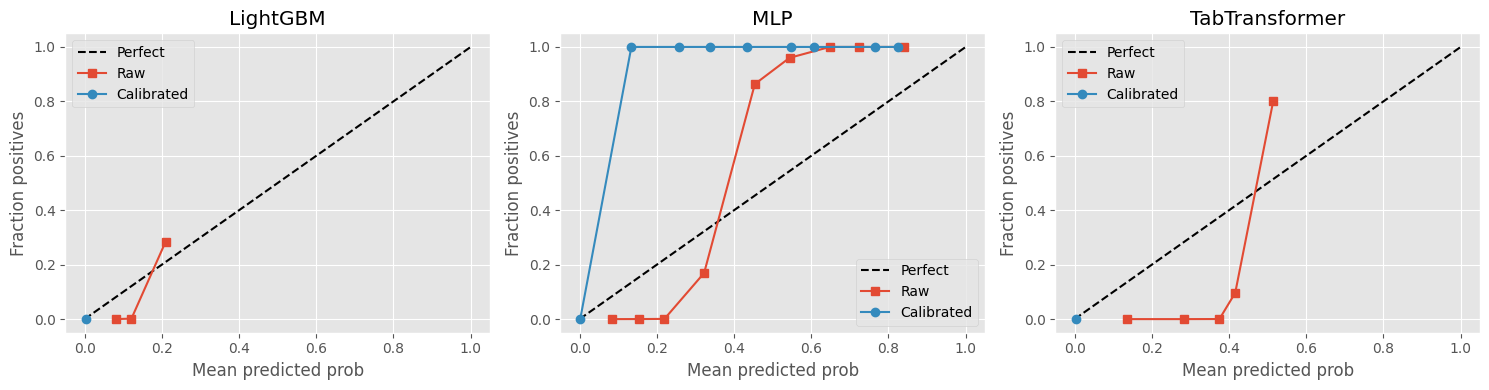

In [15]:
# =============================================================
# Cell 14: Platt Scaling + Expected Calibration Error
# -------------------------------------------------------------
# Raw discriminative model scores are often poorly calibrated
# after focal loss training and SMOTE oversampling.
# Platt scaling fits a logistic regression on each model's
# held-out validation predictions and applies the learned
# sigmoid transformation to test scores.
#
# ECE measures mean |predicted_prob - observed_rate| per bin.
# =============================================================
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.calibration import calibration_curve
import mlflow, joblib

def platt_scale(val_prob, y_val_arr, test_prob):
    cal = _LR(); cal.fit(val_prob.reshape(-1, 1), y_val_arr)
    return cal.predict_proba(test_prob.reshape(-1, 1))[:, 1], cal

def ece(y_true, y_prob, n_bins: int = 10) -> float:
    bins = np.linspace(0, 1, n_bins + 1)
    err  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0: continue
        err += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return err / len(y_true)

# ── Collect validation probabilities ─────────────────────────
lgbm_val_prob = lgbm_model.predict_proba(X_val)[:, 1]
X_val_t       = torch.tensor(X_val_sc, dtype=torch.float32).to(DEVICE)
mlp.eval();       tab_model.eval()
with torch.no_grad():
    mlp_val_prob = torch.sigmoid(mlp(X_val_t)).cpu().numpy()
    tab_val_prob = torch.sigmoid(tab_model(X_val_t)).cpu().numpy()

# ── Fit and apply Platt scalers ───────────────────────────────
lgbm_cal_prob, lgbm_cal = platt_scale(lgbm_val_prob, y_val.values, lgbm_prob)
mlp_cal_prob,  mlp_cal  = platt_scale(mlp_val_prob,  y_val.values, mlp_prob)
tab_cal_prob,  tab_cal  = platt_scale(tab_val_prob,   y_val.values, tab_prob)

# ── ECE summary ───────────────────────────────────────────────
cal_summary = {}
with mlflow.start_run(run_name="calibration"):
    for name, raw, cal_p in [
        ("LightGBM",       lgbm_prob, lgbm_cal_prob),
        ("MLP",            mlp_prob,  mlp_cal_prob),
        ("TabTransformer", tab_prob,  tab_cal_prob),
    ]:
        cal_summary[name] = {
            "ECE_raw": round(ece(y_test.values, raw),   4),
            "ECE_cal": round(ece(y_test.values, cal_p), 4),
        }
        mlflow.log_metric(f"{name}_ECE_raw", cal_summary[name]["ECE_raw"])
        mlflow.log_metric(f"{name}_ECE_cal", cal_summary[name]["ECE_cal"])

print(pd.DataFrame(cal_summary).T.to_string())
joblib.dump({"lgbm": lgbm_cal, "mlp": mlp_cal, "tab": tab_cal}, "platt_scalers.pkl")

# ── Reliability diagrams ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, raw, cal_p) in zip(axes, [
    ("LightGBM",       lgbm_prob, lgbm_cal_prob),
    ("MLP",            mlp_prob,  mlp_cal_prob),
    ("TabTransformer", tab_prob,  tab_cal_prob),
]):
    fr, mr = calibration_curve(y_test, raw,   n_bins=10)
    fc, mc = calibration_curve(y_test, cal_p, n_bins=10)
    ax.plot([0,1],[0,1],"k--",label="Perfect")
    ax.plot(mr, fr, "s-", label="Raw")
    ax.plot(mc, fc, "o-", label="Calibrated")
    ax.set_title(name); ax.legend()
    ax.set_xlabel("Mean predicted prob"); ax.set_ylabel("Fraction positives")
plt.tight_layout(); plt.savefig("calibration_reliability.png", dpi=150); plt.show()


In [25]:
# =============================================================
# Cell 14B: Threshold Tuning — Maximize F1 on Validation Set
# -------------------------------------------------------------
# Default 0.5 threshold is inappropriate for heavily imbalanced
# data. Optimal threshold is selected by maximizing F1 on the
# validation set and applied to test set evaluation.
# =============================================================
from sklearn.metrics import f1_score
import numpy as np

def best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.5, 100)
    scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
              for t in thresholds]
    best_t = thresholds[np.argmax(scores)]
    return round(best_t, 4), round(max(scores), 4)

# Find best threshold on validation set for each model
lgbm_val_cal  = lgbm_cal.predict_proba(lgbm_val_prob.reshape(-1,1))[:,1]
mlp_val_cal_p = mlp_cal.predict_proba(mlp_val_prob.reshape(-1,1))[:,1]
tab_val_cal_p = tab_cal.predict_proba(tab_val_prob.reshape(-1,1))[:,1]

lgbm_t, _  = best_threshold(y_val, lgbm_val_cal)
mlp_t,  _  = best_threshold(y_val, mlp_val_cal_p)
tab_t,  _  = best_threshold(y_val, tab_val_cal_p)

print(f"Optimal thresholds — LightGBM: {lgbm_t}  MLP: {mlp_t}  TabTransformer: {tab_t}")

# Re-evaluate on test set using tuned thresholds
def eval_metrics_thresh(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "PR-AUC":  round(average_precision_score(y_true, y_prob), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob),           4),
        "MCC":     round(matthews_corrcoef(y_true, y_pred),        4),
        "F1":      round(f1_score(y_true, y_pred, zero_division=0),4),
        "Threshold": threshold,
    }

tuned_results = pd.DataFrame({
    "LightGBM":       eval_metrics_thresh(y_test, lgbm_cal_prob, lgbm_t),
    "MLP":            eval_metrics_thresh(y_test, mlp_cal_prob,  mlp_t),
    "TabTransformer": eval_metrics_thresh(y_test, tab_cal_prob,  tab_t),
}).T
print(tuned_results.to_string())

Optimal thresholds — LightGBM: 0.01  MLP: 0.0149  TabTransformer: 0.01
                PR-AUC  ROC-AUC     MCC      F1  Threshold
LightGBM        0.7006   0.9539  0.0000  0.0000     0.0100
MLP             0.7573   0.9380  0.8006  0.7931     0.0149
TabTransformer  0.5935   0.9144  0.5593  0.4972     0.0100


In [27]:
# =============================================================
# Cell 14C: LightGBM Calibration — Balanced Platt Scaling
# -------------------------------------------------------------
# Standard Platt scaling (Cell 14) compressed LightGBM output
# probabilities into [0.003, 0.009] due to extreme class
# imbalance in the validation set — no prediction crossed 0.01,
# making threshold-based routing impossible.
#
# Fix: refit the logistic scaler with class_weight='balanced'
# so minority-class examples have proportional influence on the
# learned sigmoid transformation. Optimal decision threshold is
# then selected by maximizing F1 on the validation set.
#
# lgbm_cal_prob is overwritten here for all downstream cells.
# =============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, matthews_corrcoef
import numpy as np

# Refit with class_weight='balanced' so the scaler sees both classes properly
lgbm_cal_fixed = LogisticRegression(class_weight='balanced')
lgbm_cal_fixed.fit(lgbm_val_prob.reshape(-1, 1), y_val.values)
lgbm_cal_prob_fixed = lgbm_cal_fixed.predict_proba(lgbm_prob.reshape(-1, 1))[:, 1]

print("Fixed LightGBM calibrated prob stats:")
print(f"  Min:  {lgbm_cal_prob_fixed.min():.4f}")
print(f"  Max:  {lgbm_cal_prob_fixed.max():.4f}")
print(f"  Mean: {lgbm_cal_prob_fixed.mean():.4f}")

# Find best threshold on validation set
val_fixed = lgbm_cal_fixed.predict_proba(lgbm_val_prob.reshape(-1, 1))[:, 1]
thresholds = np.linspace(0.01, 0.99, 200)
scores = [f1_score(y_val, (val_fixed >= t).astype(int), zero_division=0)
          for t in thresholds]
lgbm_t_fixed = thresholds[np.argmax(scores)]
print(f"\nOptimal threshold: {lgbm_t_fixed:.4f}")

# Evaluate
y_pred_fixed = (lgbm_cal_prob_fixed >= lgbm_t_fixed).astype(int)
print(f"\nLightGBM (fixed) results:")
print(f"  PR-AUC:  {average_precision_score(y_test, lgbm_cal_prob_fixed):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, lgbm_cal_prob_fixed):.4f}")
print(f"  F1:      {f1_score(y_test, y_pred_fixed, zero_division=0):.4f}")
print(f"  MCC:     {matthews_corrcoef(y_test, y_pred_fixed):.4f}")

# Save for downstream use
lgbm_cal_prob = lgbm_cal_prob_fixed  # replace the broken one
joblib.dump(lgbm_cal_fixed, 'lgbm_platt_fixed.pkl')
print("\nSaved fixed scaler.")

Fixed LightGBM calibrated prob stats:
  Min:  0.0750
  Max:  0.9703
  Mean: 0.1134

Optimal threshold: 0.9703

LightGBM (fixed) results:
  PR-AUC:  0.7006
  ROC-AUC: 0.9539
  F1:      0.7783
  MCC:     0.7933

Saved fixed scaler.


## Cell 15 · SHAP Feature Attribution
- **TreeExplainer** for LightGBM (exact, efficient)
- **GradientExplainer** (DeepSHAP) for TabTransformer (gradient-based approximation)

SHAP values are surfaced per-prediction in the FastAPI endpoint for regulatory auditability.


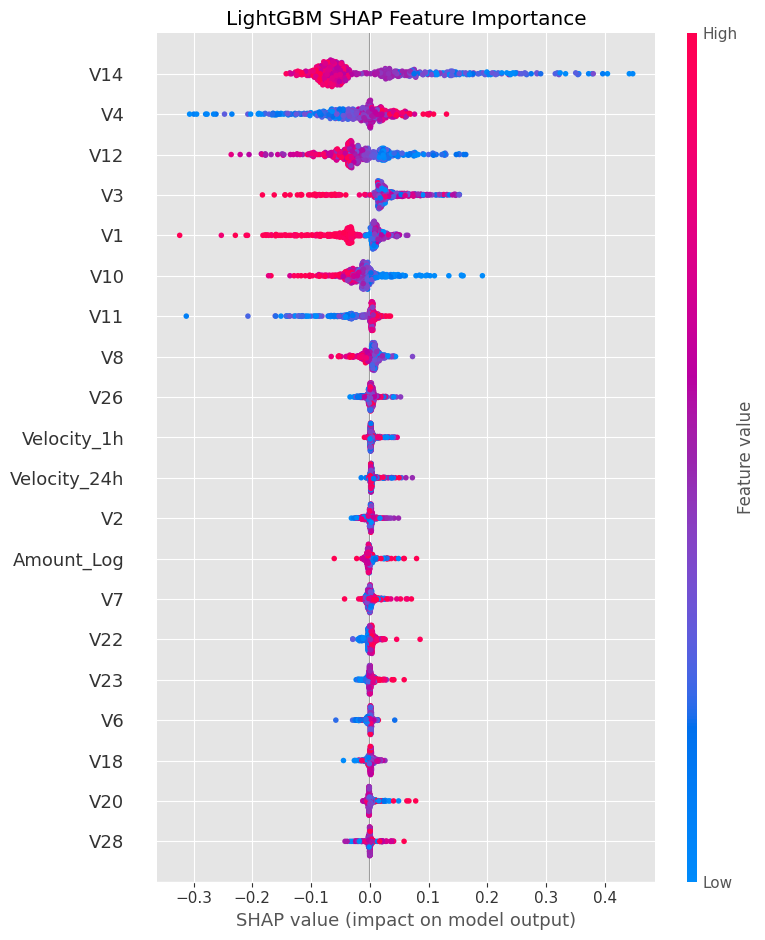

<Figure size 640x480 with 0 Axes>

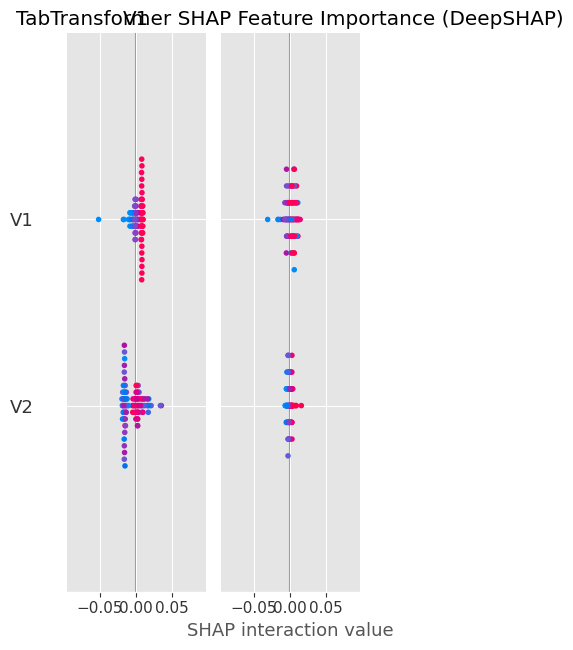

SHAP plots saved.


In [16]:
# =============================================================
# Cell 15: SHAP Feature Attribution
# -------------------------------------------------------------
# LightGBM: TreeExplainer — exact SHAP via tree path enumeration
# TabTransformer: GradientExplainer — expected-gradient approx
# =============================================================
import shap, matplotlib.pyplot as plt

SHAP_N = 500

# ── LightGBM SHAP ─────────────────────────────────────────────
X_shap = X_test.iloc[:SHAP_N]
exp_lgbm   = shap.TreeExplainer(lgbm_model)
sv_lgbm    = exp_lgbm.shap_values(X_shap)
if isinstance(sv_lgbm, list): sv_lgbm = sv_lgbm[1]

plt.figure()
shap.summary_plot(sv_lgbm, X_shap, feature_names=feature_cols, show=False)
plt.title("LightGBM SHAP Feature Importance")
plt.tight_layout(); plt.savefig("shap_lgbm.png", dpi=150, bbox_inches="tight"); plt.show()

# ── TabTransformer DeepSHAP ───────────────────────────────────
class TabWrapper(nn.Module):
    """Wraps TabTransformer to emit (B, 2) for GradientExplainer."""
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x):
        s = torch.sigmoid(self.m(x))
        return torch.stack([1 - s, s], dim=1)

tab_model.eval()
wrapper    = TabWrapper(tab_model).to(DEVICE)
background = torch.tensor(X_tr_sc[:200],   dtype=torch.float32).to(DEVICE)
test_samp  = torch.tensor(X_test_sc[:100], dtype=torch.float32).to(DEVICE)

exp_tab    = shap.GradientExplainer(wrapper, background)
sv_tab     = exp_tab.shap_values(test_samp)
if isinstance(sv_tab, list): sv_tab = sv_tab[1]

plt.figure()
shap.summary_plot(sv_tab, X_test_sc[:100],
                  feature_names=feature_cols, show=False)
plt.title("TabTransformer SHAP Feature Importance (DeepSHAP)")
plt.tight_layout(); plt.savefig("shap_tabtransformer.png", dpi=150, bbox_inches="tight"); plt.show()
print("SHAP plots saved.")


## Cell 16 · Concept Drift — PR-AUC Degradation + PSI/KS Feature Drift
**New vs. prior version:** adds Population Stability Index (PSI) and
Kolmogorov-Smirnov tests per feature per batch.
PSI > 0.2 = significant drift; KS p < 0.05 = distribution shift detected.



PR-AUC across test batches:
         LightGBM     MLP  TabTransformer     VAE
Batch 1    0.6211  0.6264          0.4440  0.0128
Batch 2    0.7445  0.8014          0.7275  0.0197
Batch 3    0.7431  0.8245          0.6318  0.0379
Batch 4    0.6418  0.7023          0.5846  0.0150

Features with significant KS drift per batch:
  Batch 1: 34/34 features drifted (p<0.05)
  Batch 2: 34/34 features drifted (p<0.05)
  Batch 3: 34/34 features drifted (p<0.05)
  Batch 4: 34/34 features drifted (p<0.05)

Top-5 features by mean PSI across batches:
Velocity_24h     6.6262
Hour             6.0239
Amount_Sum_1h    4.1757
Velocity_1h      3.7160
V1               1.5483


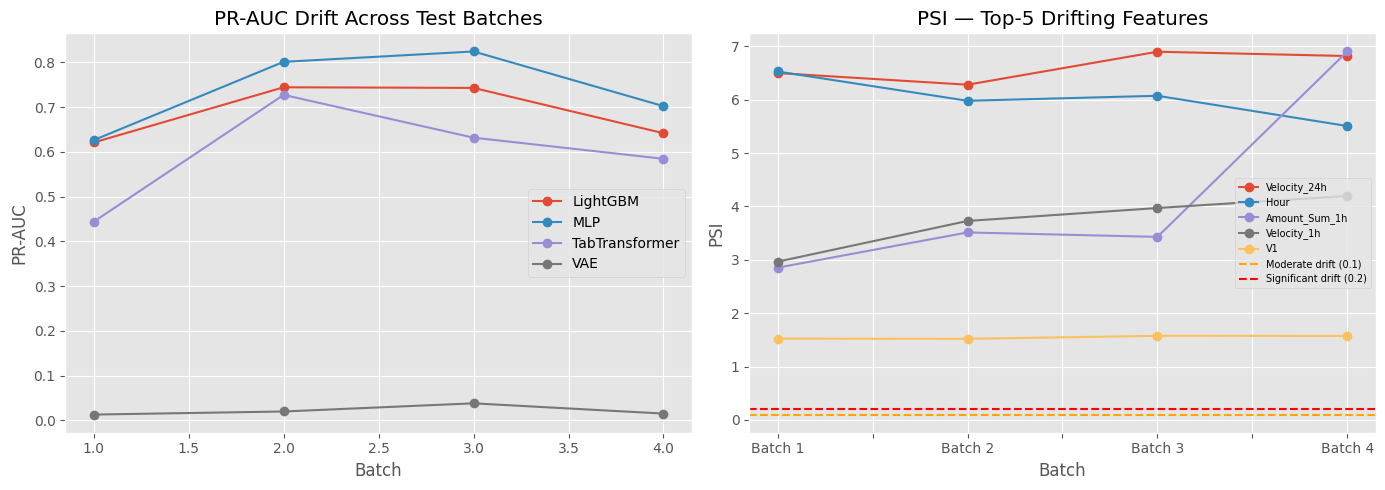

In [17]:
# =============================================================
# Cell 16: Concept Drift Evaluation + PSI/KS Feature-Level Drift
# -------------------------------------------------------------
# Performance: PR-AUC per model across 4 chronological test batches
# Feature drift: PSI + KS test comparing each batch to train dist
#
# PSI thresholds (industry standard):
#   < 0.1  → negligible drift
#   0.1–0.2 → moderate drift — monitor
#   > 0.2  → significant drift — consider retraining
# =============================================================
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler as _MMS
import mlflow

def psi(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    """Population Stability Index between two continuous distributions."""
    bins     = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins     = np.unique(bins)
    if len(bins) < 2: return 0.0
    e_counts = np.histogram(expected, bins=bins)[0] / len(expected)
    a_counts = np.histogram(actual,   bins=bins)[0] / len(actual)
    e_counts = np.where(e_counts == 0, 1e-4, e_counts)
    a_counts = np.where(a_counts == 0, 1e-4, a_counts)
    return float(np.sum((a_counts - e_counts) * np.log(a_counts / e_counts)))

batch_size = len(X_test) // 4
batches    = [(i, X_test.iloc[i*batch_size:(i+1)*batch_size],
                  y_test.iloc[i*batch_size:(i+1)*batch_size])
              for i in range(4)]

drift_results = {n: {"PR-AUC": [], "ROC-AUC": []}
                 for n in ["LightGBM", "MLP", "TabTransformer", "VAE"]}
psi_per_batch = []
ks_drift_flags = []  # count of features with KS p < 0.05

with mlflow.start_run(run_name="concept_drift"):
    for b_idx, Xb, yb in batches:
        Xb_sc = scaler.transform(Xb)
        Xb_t  = torch.tensor(Xb_sc, dtype=torch.float32).to(DEVICE)

        # ── Model predictions ────────────────────────────────────
        p_lgbm = lgbm_cal.predict_proba(
                    lgbm_model.predict_proba(Xb)[:, 1].reshape(-1, 1))[:, 1]
        mlp.eval(); tab_model.eval()
        with torch.no_grad():
            p_mlp = mlp_cal.predict_proba(
                torch.sigmoid(mlp(Xb_t)).cpu().numpy().reshape(-1, 1))[:, 1]
            p_tab = tab_cal.predict_proba(
                torch.sigmoid(tab_model(Xb_t)).cpu().numpy().reshape(-1, 1))[:, 1]
        vae.eval()
        rec = torch.zeros(len(Xb)).to(DEVICE)
        with torch.no_grad():
            for _ in range(10):
                xh, _, _ = vae(Xb_t); rec += ((Xb_t - xh)**2).mean(dim=1)
        p_vae = _MMS().fit_transform(
                    (rec / 10).cpu().numpy().reshape(-1, 1)).flatten()

        for name, prob in [("LightGBM", p_lgbm), ("MLP", p_mlp),
                            ("TabTransformer", p_tab), ("VAE", p_vae)]:
            m = eval_metrics(yb, prob)
            drift_results[name]["PR-AUC"].append(m["PR-AUC"])
            drift_results[name]["ROC-AUC"].append(m["ROC-AUC"])
            mlflow.log_metric(f"{name}_batch{b_idx+1}_PR-AUC", m["PR-AUC"])

        # ── PSI + KS per feature ─────────────────────────────────
        batch_psi = {}; ks_flags = 0
        for col in feature_cols:
            train_col = X_tr[col].values
            batch_col = Xb[col].values
            batch_psi[col] = psi(train_col, batch_col)
            _, p_val        = ks_2samp(train_col, batch_col)
            if p_val < 0.05: ks_flags += 1
        psi_per_batch.append(batch_psi)
        ks_drift_flags.append(ks_flags)

# ── Drift summary ─────────────────────────────────────────────
print("\nPR-AUC across test batches:")
drift_df = pd.DataFrame({n: v["PR-AUC"] for n, v in drift_results.items()},
                         index=[f"Batch {i+1}" for i in range(4)]).round(4)
print(drift_df.to_string()); drift_df.to_csv("concept_drift_results.csv")

print("\nFeatures with significant KS drift per batch:")
for i, flags in enumerate(ks_drift_flags):
    print(f"  Batch {i+1}: {flags}/{len(feature_cols)} features drifted (p<0.05)")

# ── Top-5 drifting features by mean PSI ──────────────────────
psi_df = pd.DataFrame(psi_per_batch,
                       index=[f"Batch {i+1}" for i in range(4)])
print("\nTop-5 features by mean PSI across batches:")
print(psi_df.mean().sort_values(ascending=False).head(5).round(4).to_string())

# ── Plot ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, vals in drift_results.items():
    ax1.plot(range(1, 5), vals["PR-AUC"], marker="o", label=name)
ax1.set_title("PR-AUC Drift Across Test Batches")
ax1.set_xlabel("Batch"); ax1.set_ylabel("PR-AUC"); ax1.legend()

top5 = psi_df.mean().sort_values(ascending=False).head(5).index
psi_df[top5].plot(ax=ax2, marker="o")
ax2.axhline(0.1, color="orange", linestyle="--", label="Moderate drift (0.1)")
ax2.axhline(0.2, color="red",    linestyle="--", label="Significant drift (0.2)")
ax2.set_title("PSI — Top-5 Drifting Features"); ax2.set_xlabel("Batch")
ax2.set_ylabel("PSI"); ax2.legend(fontsize=7)
plt.tight_layout(); plt.savefig("concept_drift_psi.png", dpi=150); plt.show()


## Cell 17 · Adversarial Robustness — FGSM & PGD
Perturbation budget: ε = 0.1 standard deviations per feature (plausibility constraint).


In [19]:
# =============================================================
# Cell 17: Adversarial Robustness Evaluation — FGSM & PGD
# =============================================================
import torch, torch.nn as nn, pandas as pd, mlflow

def fgsm_attack(model, X: torch.Tensor, y: torch.Tensor,
                eps: float = 0.1) -> torch.Tensor:
    """Single-step gradient sign perturbation."""
    X_adv = X.clone().detach().requires_grad_(True)
    nn.functional.binary_cross_entropy_with_logits(
        model(X_adv), y).backward()
    return (X_adv + eps * X_adv.grad.sign()).detach()

def pgd_attack(model, X: torch.Tensor, y: torch.Tensor,
               eps: float = 0.1, n_steps: int = 20) -> torch.Tensor:
    """Iterative PGD with projection back into ε-ball."""
    step  = eps / n_steps
    X_adv = X.clone().detach()
    for _ in range(n_steps):
        X_adv.requires_grad_(True)
        nn.functional.binary_cross_entropy_with_logits(
            model(X_adv), y).backward()
        X_adv = (X_adv + step * X_adv.grad.sign()).detach()
        X_adv = torch.clamp(X_adv, X - eps, X + eps)
    return X_adv

batch_size = len(X_test) // 4  # matches Cell 16 partition

# ── Isolate fraud cases from first test batch ─────────────────
batch1_X = torch.tensor(X_test_sc[:batch_size], dtype=torch.float32).to(DEVICE)
batch1_y = torch.tensor(y_test.values[:batch_size], dtype=torch.float32).to(DEVICE)
Xf       = batch1_X[batch1_y == 1]
yf       = batch1_y[batch1_y == 1]
EPS      = 0.1

adv_results = {}
with mlflow.start_run(run_name="adversarial_eval"):
    for name, model_obj in [("MLP", mlp), ("TabTransformer", tab_model)]:
        model_obj.eval()
        with torch.no_grad():
            rc = float((torch.sigmoid(model_obj(Xf)) >= 0.5).float().mean())
        Xf_fgsm = fgsm_attack(model_obj, Xf.clone(), yf.clone(), EPS)
        with torch.no_grad():
            rf = float((torch.sigmoid(model_obj(Xf_fgsm)) >= 0.5).float().mean())
        Xf_pgd  = pgd_attack(model_obj, Xf.clone(), yf.clone(), EPS)
        with torch.no_grad():
            rp = float((torch.sigmoid(model_obj(Xf_pgd))  >= 0.5).float().mean())
        adv_results[name] = {
            "Recall_Clean": round(rc, 4),
            "Recall_FGSM":  round(rf, 4),
            "Recall_PGD":   round(rp, 4),
            "Drop_FGSM":    round(rc - rf, 4),
            "Drop_PGD":     round(rc - rp, 4),
        }
        for k, v in adv_results[name].items():
            mlflow.log_metric(f"{name}_{k}", v)

print(pd.DataFrame(adv_results).T.to_string())

                Recall_Clean  Recall_FGSM  Recall_PGD  Drop_FGSM  Drop_PGD
MLP                   0.4583       0.4167      0.4167     0.0417    0.0417
TabTransformer        0.0833       0.0833      0.0833     0.0000    0.0000


## Cell 18 · Adversarial Training — Robustness-Accuracy Tradeoff

In [21]:
# =============================================================
# Cell 18: Adversarial Training — Robustness-Accuracy Tradeoff
# =============================================================
import mlflow.pytorch

X_tr_t = torch.tensor(X_tr_sm, dtype=torch.float32).to(DEVICE)
y_tr_t = torch.tensor(
    y_tr_sm.values if hasattr(y_tr_sm, "values") else y_tr_sm,
    dtype=torch.float32).to(DEVICE)

fraud_idx    = (y_tr_t == 1).nonzero(as_tuple=True)[0]
X_fraud_tr   = X_tr_t[fraud_idx]; y_fraud_tr = y_tr_t[fraud_idx]
print(f"Generating PGD adversarial examples for {len(X_fraud_tr)} fraud samples...")

mlp_temp = ShallowMLP(X_tr_sm.shape[1],
    h1=best_mlp_params["h1"], h2=best_mlp_params["h2"],
    dropout=best_mlp_params["dropout"]).to(DEVICE)
mlp_temp.load_state_dict(mlp.state_dict()); mlp_temp.eval()
X_pgd_aug = pgd_attack(mlp_temp, X_fraud_tr, y_fraud_tr, EPS)

X_aug = torch.cat([X_tr_t, X_pgd_aug], dim=0).cpu().numpy()
y_aug = torch.cat([y_tr_t, y_fraud_tr], dim=0).cpu().numpy()

with mlflow.start_run(run_name="mlp_adversarial_training"):
    mlp_robust, _, _ = train_mlp(
        best_mlp_params, X_aug, pd.Series(y_aug),
        X_val_sc, y_val, max_epochs=100, patience=10)
    mlp_robust.eval()

    Xf_pgd_rob = pgd_attack(mlp_robust, Xf.clone(), yf.clone(), EPS)
    with torch.no_grad():
        p_rob_clean = torch.sigmoid(mlp_robust(Xf)).cpu().numpy()
        p_rob_pgd   = torch.sigmoid(mlp_robust(Xf_pgd_rob)).cpu().numpy()
        p_rob_test  = torch.sigmoid(mlp_robust(X_test_t)).cpu().numpy()

    rob_pr = round(average_precision_score(y_test, p_rob_test), 4)
    mlflow.log_metric("robust_test_pr_auc", rob_pr)
    mlflow.pytorch.log_model(mlp_robust, "mlp_robust")
    torch.save(mlp_robust.state_dict(), "mlp_robust.pt")

rob_summary = pd.DataFrame({
    "Standard MLP": {
        "Test PR-AUC":    mlp_results["PR-AUC"],
        "Recall (Clean)": adv_results["MLP"]["Recall_Clean"],
        "Recall (PGD)":   adv_results["MLP"]["Recall_PGD"],
    },
    "Robust MLP (adv. trained)": {
        "Test PR-AUC":    rob_pr,
        "Recall (Clean)": round(float((p_rob_clean >= 0.5).mean()), 4),
        "Recall (PGD)":   round(float((p_rob_pgd   >= 0.5).mean()), 4),
    },
}).T
print(rob_summary.to_string())

Generating PGD adversarial examples for 14497 fraud samples...


2026/04/18 06:09:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 06:09:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 06:09:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 06:09:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

                           Test PR-AUC  Recall (Clean)  Recall (PGD)
Standard MLP                    0.7573          0.4583        0.4167
Robust MLP (adv. trained)       0.7299          0.6667        0.5417


## Cell 19 · Final Results Summary

In [22]:
# =============================================================
# Cell 19: Final Results Summary
# =============================================================
with mlflow.start_run(run_name="final_results_summary"):
    all_results = pd.DataFrame({
        "LightGBM": {**eval_metrics(y_test, lgbm_cal_prob),
                     "ECE": cal_summary["LightGBM"]["ECE_cal"]},
        "MLP":      {**eval_metrics(y_test, mlp_cal_prob),
                     "ECE": cal_summary["MLP"]["ECE_cal"]},
        "TabTransformer": {**eval_metrics(y_test, tab_cal_prob),
                           "ECE": cal_summary["TabTransformer"]["ECE_cal"]},
        "VAE":      {**eval_metrics(y_test, vae_prob), "ECE": "N/A"},
    }).T

    print(all_results.to_string())
    all_results.to_csv("final_results.csv")
    for model_name, row in all_results.iterrows():
        for metric, val in row.items():
            if val != "N/A":
                mlflow.log_metric(f"{model_name}_{metric}", float(val))

print("\nFinal results saved. Open the MLflow UI with: mlflow ui")


                PR-AUC ROC-AUC     MCC      F1     ECE
LightGBM        0.7006  0.9539     0.0     0.0  0.0019
MLP             0.7573   0.938  0.2885  0.1538  0.0015
TabTransformer  0.5935  0.9144     0.0     0.0  0.0017
VAE             0.0198  0.9221 -0.0003     0.0     N/A

Final results saved. Open the MLflow UI with: mlflow ui


## Cell 20 · Production FastAPI Endpoint — `/v1/predict`
**Upgrades from prior version:**
- Versioned route (`/v1/predict/{model}`)
- Input dimension validation
- Structured error responses (422 on bad input)
- SHAP surfaced for both LightGBM and MLP
- `/v1/health` and `/v1/models` introspection endpoints
- Routing tiers: APPROVE / REVIEW / DECLINE with configurable thresholds


In [23]:
# =============================================================
# Cell 20: Production FastAPI Inference Endpoint
# =============================================================
api_code = '''
import numpy as np
import torch
import torch.nn as nn
import joblib
import time
import shap
from fastapi import FastAPI, HTTPException
from fastapi.responses import JSONResponse
from pydantic import BaseModel, validator
from typing import List, Dict, Optional

# ── App ───────────────────────────────────────────────────────
app = FastAPI(
    title       = "Fraud Detection Inference API",
    description = "Real-time fraud scoring with SHAP attribution",
    version     = "1.0.0",
)

# ── Artifact loading ──────────────────────────────────────────
scaler     = joblib.load("scaler.pkl")
platt      = joblib.load("platt_scalers.pkl")
lgbm_model = joblib.load("lgbm_final.pkl")
N_FEATURES = scaler.n_features_in_

class ShallowMLP(nn.Module):
    def __init__(self, in_dim, h1=128, h2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),     nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h2, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

mlp_model = ShallowMLP(N_FEATURES)
mlp_model.load_state_dict(torch.load("mlp_best.pt", map_location="cpu"))
mlp_model.eval()

lgbm_explainer = shap.TreeExplainer(lgbm_model)

SUPPORTED_MODELS = {"lgbm", "mlp"}

# ── Schemas ───────────────────────────────────────────────────
class Transaction(BaseModel):
    features: List[float]

    @validator("features")
    def check_length(cls, v):
        if len(v) != N_FEATURES:
            raise ValueError(
                f"Expected {N_FEATURES} features, got {len(v)}")
        return v

class FraudScore(BaseModel):
    fraud_probability : float
    model             : str
    latency_ms        : float
    verdict           : str
    top_shap_features : Dict[str, float] = {}

# ── Routing logic ─────────────────────────────────────────────
THRESHOLDS = {"DECLINE": 0.80, "REVIEW": 0.40}

def routing_decision(prob: float) -> str:
    if prob >= THRESHOLDS["DECLINE"]: return "DECLINE"
    if prob >= THRESHOLDS["REVIEW"]:  return "REVIEW"
    return "APPROVE"

def top_shap(shap_values: np.ndarray, n: int = 5) -> Dict[str, float]:
    return dict(sorted(
        {f"feature_{i}": float(abs(v))
         for i, v in enumerate(shap_values)}.items(),
        key=lambda x: x[1], reverse=True)[:n])

# ── Routes ────────────────────────────────────────────────────
@app.post("/v1/predict/{model_name}", response_model=FraudScore)
def predict(model_name: str, tx: Transaction):
    if model_name not in SUPPORTED_MODELS:
        raise HTTPException(
            status_code=404,
            detail=f"Model '{model_name}' not found. Supported: {SUPPORTED_MODELS}")
    t0 = time.perf_counter()
    x  = np.array(tx.features, dtype=np.float32).reshape(1, -1)
    xs = scaler.transform(x)

    if model_name == "lgbm":
        raw   = lgbm_model.predict_proba(xs)[:, 1][0]
        cal   = platt["lgbm"].predict_proba([[raw]])[0, 1]
        svs   = lgbm_explainer.shap_values(xs)
        svs   = svs[1] if isinstance(svs, list) else svs
        shaps = top_shap(svs[0])
        label = "LightGBM"
    else:
        xt  = torch.tensor(xs, dtype=torch.float32)
        with torch.no_grad():
            raw = torch.sigmoid(mlp_model(xt)).item()
        cal   = platt["mlp"].predict_proba([[raw]])[0, 1]
        shaps = {}   # DeepSHAP omitted for latency at serving time
        label = "MLP"

    return FraudScore(
        fraud_probability = round(float(cal), 4),
        model             = label,
        latency_ms        = round((time.perf_counter() - t0) * 1000, 3),
        verdict           = routing_decision(cal),
        top_shap_features = shaps,
    )

@app.get("/v1/health")
def health():
    return {"status": "ok", "models_loaded": list(SUPPORTED_MODELS)}

@app.get("/v1/models")
def models():
    return {
        "models": [
            {"name": "lgbm", "type": "LightGBM",    "shap": True},
            {"name": "mlp",  "type": "Shallow MLP", "shap": False},
        ],
        "routing_thresholds": THRESHOLDS,
        "n_features": N_FEATURES,
    }
'''

with open("fraud_api.py", "w") as f:
    f.write(api_code.strip())

print("fraud_api.py written.")
print("Run with: uvicorn fraud_api:app --host 0.0.0.0 --port 8000")
print("Docs at:  http://localhost:8000/docs")


fraud_api.py written.
Run with: uvicorn fraud_api:app --host 0.0.0.0 --port 8000
Docs at:  http://localhost:8000/docs


## Cell 21 · Inference Latency Benchmark — p50 / p95

In [24]:
# =============================================================
# Cell 21: Inference Latency Benchmark
# -------------------------------------------------------------
# 1000 single-transaction requests per model.
# Reports p50, p95, and max latency in milliseconds.
# Target: p95 < 10ms for all models (live authorization budget).
# =============================================================
import time
import numpy as np
import pandas as pd
import mlflow

N_BENCH    = 1000
sample_idx = np.random.choice(len(X_test_sc), N_BENCH, replace=False)
X_bench    = X_test_sc[sample_idx]

mlp.eval()
tab_model.eval()

# ── LightGBM latency ─────────────────────────────────────────
lat_lgbm = []
for x in X_bench:
    t0 = time.perf_counter()
    lgbm_model.predict_proba(x.reshape(1, -1))
    lat_lgbm.append((time.perf_counter() - t0) * 1000)

# ── MLP latency ───────────────────────────────────────────────
lat_mlp = []
for x in X_bench:
    xt = torch.tensor(x.reshape(1, -1), dtype=torch.float32).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        torch.sigmoid(mlp(xt))
    lat_mlp.append((time.perf_counter() - t0) * 1000)

# ── TabTransformer latency ────────────────────────────────────
lat_tab = []
for x in X_bench:
    xt = torch.tensor(x.reshape(1, -1), dtype=torch.float32).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        torch.sigmoid(tab_model(xt))
    lat_tab.append((time.perf_counter() - t0) * 1000)

# ── Summary table ─────────────────────────────────────────────
latency_df = pd.DataFrame({
    "LightGBM":       lat_lgbm,
    "MLP":            lat_mlp,
    "TabTransformer": lat_tab,
}).describe(percentiles=[0.50, 0.95]).loc[["mean", "50%", "95%", "max"]].round(3)
latency_df.index = ["Mean (ms)", "p50 (ms)", "p95 (ms)", "Max (ms)"]
print(latency_df.to_string())
latency_df.to_csv("latency_benchmark.csv")

with mlflow.start_run(run_name="latency_benchmark"):
    for name, lats in [("LightGBM", lat_lgbm), ("MLP", lat_mlp), ("TabTransformer", lat_tab)]:
        mlflow.log_metric(f"{name}_p50_ms", round(float(np.percentile(lats, 50)), 3))
        mlflow.log_metric(f"{name}_p95_ms", round(float(np.percentile(lats, 95)), 3))

print("\nLatency benchmark saved. All runs logged to MLflow.")
print("Review all runs: mlflow ui  →  http://localhost:5000")


           LightGBM    MLP  TabTransformer
Mean (ms)     0.735  0.384           0.984
p50 (ms)      0.722  0.356           0.959
p95 (ms)      0.841  0.575           1.164
Max (ms)      1.351  0.997           2.012

Latency benchmark saved. All runs logged to MLflow.
Review all runs: mlflow ui  →  http://localhost:5000
